Step 1: Data Wrangle

In [2]:
#Grab Data
import yfinance as yf


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# PyPortfolioOpt for Calculations
from pypfopt import EfficientFrontier, objective_functions
from pypfopt import black_litterman, risk_models
from pypfopt import BlackLittermanModel, plotting
from pypfopt import DiscreteAllocation

In [3]:
#Create a Portfolio
symbols = [
    'AAPL',
    'MSFT',
    'META',
    'AMZN',
    'XOM',
    'UNH',
    'JNJ',
    'V',
    'HD',
    'ABBV',
    'KO',
    'DIS',
    'T',
    'UPS',
    'LMT',
    'CAT',
    'F',
    'MAR',
    'O',
    'HSY'
]

In [4]:
#Get the stock data
portfolio = yf.download(symbols, start="2018-01-01", end="2026-02-15")['Close']
portfolio.head()



[*********************100%***********************]  20 of 20 completed


Ticker,AAPL,ABBV,AMZN,CAT,DIS,F,HD,HSY,JNJ,KO,LMT,MAR,META,MSFT,O,T,UNH,UPS,V,XOM
Date,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.304173,69.343697,59.450500,131.543839,106.224518,8.174584,154.821121,92.064690,111.353027,35.492737,257.274445,125.140388,180.161514,78.870354,37.233177,16.087729,194.591644,89.841103,108.111916,58.580429
2018-01-03,40.297161,70.428871,60.209999,131.744904,106.680588,8.239154,155.628021,91.678734,112.416725,35.414791,259.431030,127.666603,183.388977,79.237427,37.134544,15.716214,196.632874,91.831589,109.188202,59.730953
2018-01-04,40.484333,70.027214,60.479500,133.554199,106.633095,8.381206,156.863113,92.319283,112.408737,35.913589,263.881134,126.964844,183.051315,79.934830,36.332245,15.862313,197.486374,92.427307,109.594185,59.813637
2018-01-05,40.945259,71.246223,61.457001,135.665100,106.053497,8.523260,158.501587,92.762741,113.336479,35.905796,266.271851,125.748520,185.553848,80.925858,36.305946,15.920756,201.252197,92.710632,112.218857,59.765396
2018-01-08,40.793186,70.104713,62.343498,139.074326,104.533295,8.490978,158.122910,93.666046,113.480431,35.851250,265.044281,127.563637,186.973938,81.008446,36.351994,15.966674,197.759094,93.836624,112.672043,60.034088


In [6]:
#SP500 ETF Benchmark
market_prices = yf.download("SPY", start='2018-01-01', end='2023-02-28')["Close"]
market_prices.head()


[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2018-01-02,237.208221
2018-01-03,238.708603
2018-01-04,239.714630
2018-01-05,241.312271
2018-01-08,241.753479


In [7]:
#Grap Market Capitalization for each stock in portfolio
mcaps = {}
for t in symbols:
    stock = yf.Ticker(t)
    mcaps[t] = stock.info["marketCap"]
mcaps


{'AAPL': 4005887213568,
 'MSFT': 2985437429760,
 'META': 1646968307712,
 'AMZN': 2229642985472,
 'XOM': 621951975424,
 'UNH': 262371606528,
 'JNJ': 587677958144,
 'V': 611776593920,
 'HD': 378050478080,
 'ABBV': 397864534016,
 'KO': 346623672320,
 'DIS': 188174090240,
 'T': 197051252736,
 'UPS': 98100969472,
 'LMT': 148684423168,
 'CAT': 342614867968,
 'F': 58326130688,
 'MAR': 92826738688,
 'O': 62556557312,
 'HSY': 46946783232}

The first line computes the covariance matrix of asset returns using the Ledoit–Wolf shrinkage estimator, which provides a more stable and robust estimate of risk than the standard sample covariance matrix.

The second line estimates the market-implied risk aversion coefficient (δ) within the Black–Litterman framework; this parameter is then used to compute the equilibrium implied returns of the market.


In [8]:
#Calculate Sigma and Delta to get implied market returns
#Ledoit-Wolf is a particular form of shrinkage, where the shrinkage coefficient is computed using O?
S = risk_models.CovarianceShrinkage(portfolio).ledoit_wolf()

delta = black_litterman.market_implied_risk_aversion(market_prices)
delta

np.float64(2.5268912945851323)

<Axes: xlabel='Ticker', ylabel='Ticker'>

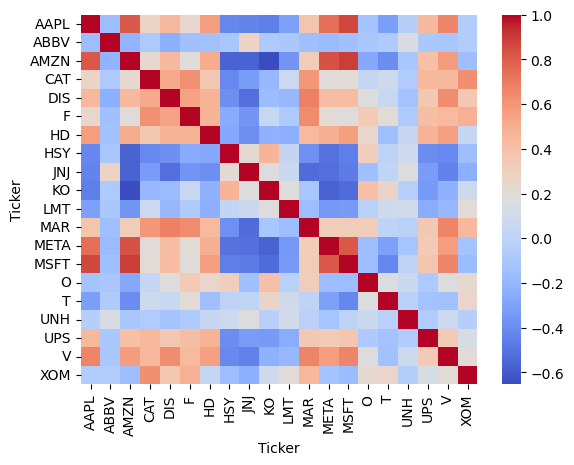

In [9]:
#Visualize the Covariant Correlation
sns.heatmap(S.corr(), cmap='coolwarm')

Equilibrium (implied) returns consistent with a mean–variance optimal market portfolio

In [10]:
market_prior = black_litterman.market_implied_prior_returns(mcaps, delta, S)
market_prior

Ticker
AAPL    0.154507
ABBV    0.057622
AMZN    0.156440
CAT     0.093677
DIS     0.099344
F       0.101161
HD      0.095387
HSY     0.039560
JNJ     0.043481
KO      0.046628
LMT     0.049404
MAR     0.102211
META    0.175374
MSFT    0.142558
O       0.061183
T       0.048040
UNH     0.072546
UPS     0.086744
V       0.105071
XOM     0.069168
dtype: float64

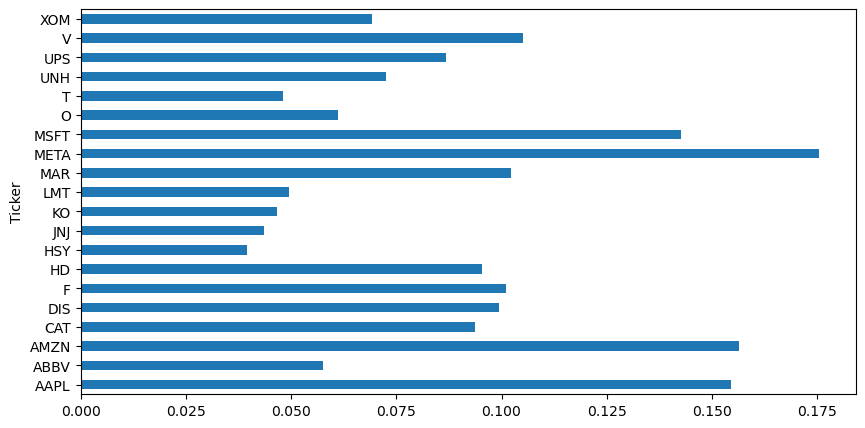

In [12]:
market_prior.plot.barh(figsize=(10,5));
#Visualisation of the returns

Views Integration

In [13]:
viewdict = {
    'AAPL':0.10,
    'MSFT':0.10,
    'META':0.05,
    'AMZN':0.30,
    'XOM':0.02,
    'UNH':0.01,
    'JNJ':0.15,
    'V':0.09,
    'HD':0.16,
    'ABBV':0.07,
    'KO':0.01,
    'DIS':-0.23,
    'T':0.16,
    'UPS':0.10,
    'LMT':-0.09,
    'CAT':0.30,
    'F':0.16,
    'MAR':-0.08,
    'O':0.30,
    'HSY':-0.26
}

bl = BlackLittermanModel(S, pi=market_prior, absolute_views=viewdict)

we can calculate the uncertainty matrix directly by specifying 1 standard deviation confidence intervals, i.e bounds which we think will contain the true return 68% of the time. This may be easier than coming up with somewhat arbitrary percentage confidences

In [14]:
intervals = [
    (0, 0.25),
    (0.1, 0.4),
    (-0.1, 0.15),
    (-0.05, 0.1),
    (0.15, 0.25),
    (-0.1, 0),
    (0.1, 0.2),
    (0.08, 0.12),
    (0.1, 0.9),
    (0, 0.3),
    (0, 0.25),
    (0.1, 0.4),
    (-0.1, 0.15),
    (-0.05, 0.1),
    (0.15, 0.25),
    (-0.1, 0),
    (0.1, 0.2),
    (0.08, 0.12),
    (0.1, 0.9),
    (0, 0.3),
]


Each view represents an expected return for an asset or a combination of assets.

For each view, a confidence interval around the expected return is defined, typically ±1 standard deviation (σ), covering ~68% of possible outcomes.

These variances form the diagonal of Ω, the uncertainty matrix.

Intuition:

Small variance → view is highly confident → strong influence on adjusted returns

Large variance → view is uncertain → weak influence

Intervals should be justified, not arbitrary, using: historical volatility, expert judgment, or consensus benchmarks.

Example: view = 0.2, interval = [0.1, 0.3] → σ = 0.1 → variance = 0.01 → used in Ω to weight this view in Black–Litterman.

Summary: Ω translates the confidence in each view into variance, which determines how strongly each view will adjust the market-implied returns and ultimately the portfolio allocation.

In [15]:
variances = []
for lb, ub in intervals:
    sigma = (ub - lb)/2
    variances.append(sigma ** 2)

print(variances)
omega = np.diag(variances)

[0.015625, 0.022500000000000006, 0.015625, 0.0056250000000000015, 0.0025000000000000005, 0.0025000000000000005, 0.0025000000000000005, 0.00039999999999999986, 0.16000000000000003, 0.0225, 0.015625, 0.022500000000000006, 0.015625, 0.0056250000000000015, 0.0025000000000000005, 0.0025000000000000005, 0.0025000000000000005, 0.00039999999999999986, 0.16000000000000003, 0.0225]


Calculate Posterior Estimate Returns

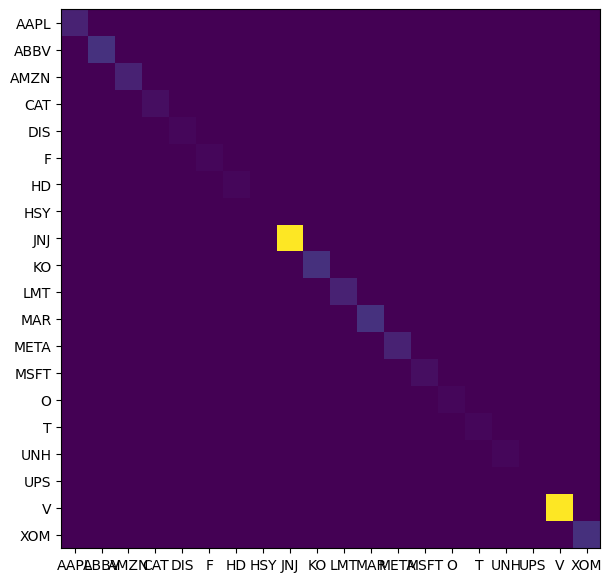

In [17]:
fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(omega)

# We want to show all ticks...
ax.set_xticks(np.arange(len(bl.tickers)))
ax.set_yticks(np.arange(len(bl.tickers)))

ax.set_xticklabels(bl.tickers)
ax.set_yticklabels(bl.tickers)
plt.show()

Heatmap of the uncertainty matrix Ω
Shows the confidence of each view for every asset (darker = more confident, lighter = less confident)


In [20]:
bl = BlackLittermanModel(
    S,                 # Covariance matrix
    pi="market",       # Use market-implied prior returns
    market_caps=mcaps, # Market cap weights
    risk_aversion=delta,
    absolute_views=viewdict, # views over certain stocks
    omega=omega             # uncertainty associated to views
)

In [21]:
# Posterior estimate of returns
ret_bl = bl.bl_returns()
ret_bl

Ticker
AAPL    0.146956
ABBV    0.063699
AMZN    0.199138
CAT     0.189033
DIS     0.041771
F       0.129323
HD      0.091616
HSY     0.006042
JNJ     0.077206
KO      0.026447
LMT    -0.011926
MAR    -0.061077
META    0.153692
MSFT    0.142579
O       0.014422
T       0.054708
UNH     0.028587
UPS     0.102800
V       0.085543
XOM     0.040181
dtype: float64

Adjusted returns with the Views

In [22]:
rets_df = pd.DataFrame([market_prior, ret_bl, pd.Series(viewdict)],
             index=["Prior", "Posterior", "Views"]).T
rets_df

,Prior,Posterior,Views
AAPL,0.154507,0.146956,0.10
ABBV,0.057622,0.063699,0.07
AMZN,0.156440,0.199138,0.30
CAT,0.093677,0.189033,0.30
DIS,0.099344,0.041771,-0.23
F,0.101161,0.129323,0.16
HD,0.095387,0.091616,0.16
HSY,0.039560,0.006042,-0.26
JNJ,0.043481,0.077206,0.15
KO,0.046628,0.026447,0.01


<Axes: >

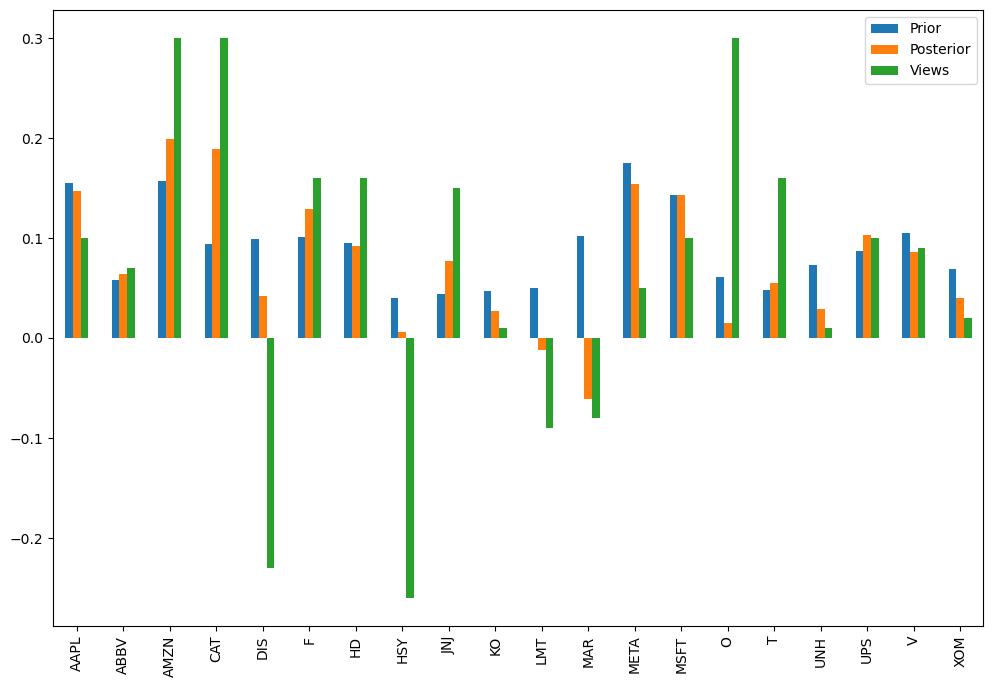

In [24]:
rets_df.plot.bar(figsize=(12,8))

<Axes: >

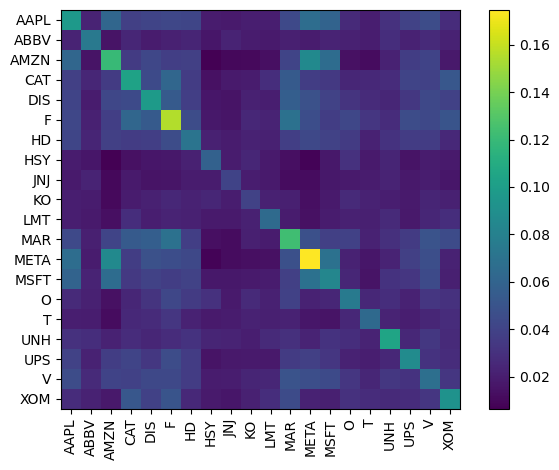

In [25]:
S_bl = bl.bl_cov()
plotting.plot_covariance(S_bl)

Portfolio Allocation

In [26]:
ef = EfficientFrontier(ret_bl, S_bl)
ef.add_objective(objective_functions.L2_reg)
ef.max_sharpe()
weights = ef.clean_weights()
weights

/home/72eb6b62-3f4d-4dce-8445-abd6ba2845b6/.local/lib/python3.12/site-packages/pypfopt/efficient_frontier/efficient_frontier.py:259: UserWarning: max_sharpe transforms the optimization problem so additional objectives may not work as expected.
  warnings.warn(


OrderedDict([('AAPL', 0.09969),
             ('ABBV', 0.04131),
             ('AMZN', 0.14835),
             ('CAT', 0.14674),
             ('DIS', 0.00309),
             ('F', 0.0812),
             ('HD', 0.05521),
             ('HSY', 0.0),
             ('JNJ', 0.06118),
             ('KO', 0.0085),
             ('LMT', 0.0),
             ('MAR', 0.0),
             ('META', 0.09545),
             ('MSFT', 0.09768),
             ('O', 0.0),
             ('T', 0.03417),
             ('UNH', 0.00223),
             ('UPS', 0.06661),
             ('V', 0.0479),
             ('XOM', 0.01066)])

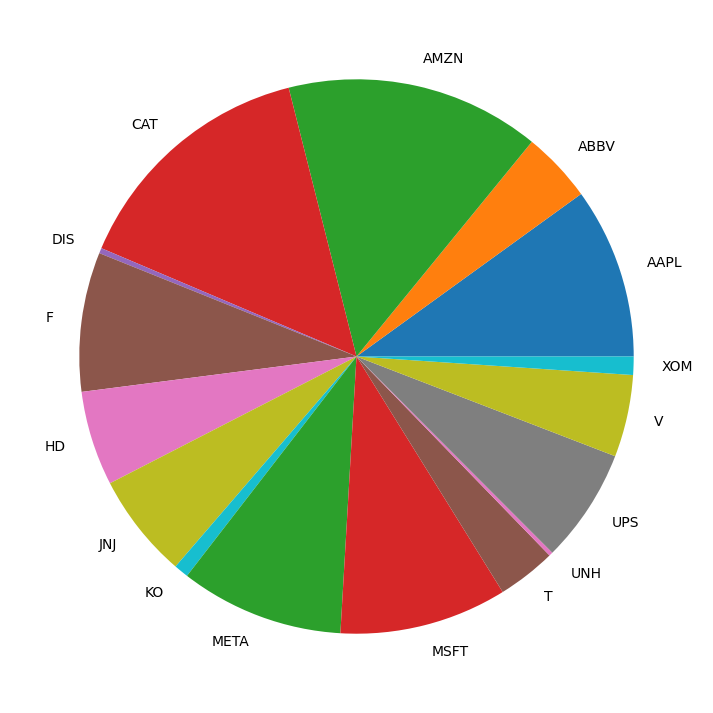

In [27]:
pd.Series(weights).plot.pie(figsize=(9,9));

Expected annual return: 13.7%
Annual volatility: 21.2%
Sharpe Ratio: 0.65


/home/72eb6b62-3f4d-4dce-8445-abd6ba2845b6/.local/lib/python3.12/site-packages/pypfopt/efficient_frontier/efficient_frontier.py:441: UserWarning: The risk_free_rate provided to portfolio_performance is different to the one used by max_sharpe. Using the previous value.
  warnings.warn(


(np.float64(0.13710462699530696),
 np.float64(0.2121026511786519),
 np.float64(0.6464069460396566))

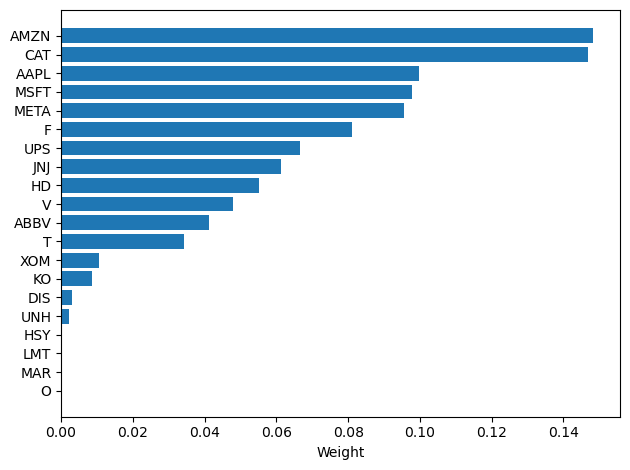

In [29]:
from pypfopt.plotting import plot_weights


plot_weights(weights)
ef.portfolio_performance(verbose = True, risk_free_rate = 0.009)